# 🏏 CricWeatherAI — Notebook 2: Feature Engineering
**Final Year Project** | Cricket Match Outcome Predictor with Weather Fusion

This notebook builds your **3 original features** that nobody else has:
1. 🌬️ **Weather Swing Score** — swing bowling potential from weather
2. 💧 **Dew Probability Index** — evening dew impact on T20 chases  
3. 🏟️ **Pitch Decay Factor** — how pitch changes over innings

Plus standard features: team form, head-to-head, toss advantage.

---

In [1]:
# ── Path setup: works whether this notebook is run standalone in Colab
# (e.g. uploaded individually) or from a cloned CricWeatherAI repo ──────────
import os

# If a 'CricWeatherAI' repo folder exists above us, anchor there.
# Otherwise (fresh Colab session), just work in /content as the project root.
PROJECT_ROOT = '/content'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)
print(f'✅ Working directory: {os.getcwd()}')

✅ Working directory: C:\content


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/processed/matches_with_weather.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'✅ Loaded {len(df)} matches')
df.head(2)

✅ Loaded 5271 matches


,match_id,date,venue,city,lat,lon,team1,team2,toss_winner,toss_decision,...,team1_wickets,team2_runs,team2_wickets,winner,team1_won,temp_max,humidity,cloud_cover,wind_speed,precipitation
0,211048,2005-02-17,Eden Park,Auckland,28.6139,77.209,New Zealand,Australia,Australia,bat,...,10,214,5,Australia,0,20.8,92,19,16.0,2.0
1,211028,2005-06-13,The Rose Bowl,Southampton,28.6139,77.209,England,Australia,England,bat,...,8,79,10,England,1,40.8,36,14,16.2,0.0


In [3]:
# ── FEATURE 1: Weather Swing Score (YOUR ORIGINAL CONTRIBUTION) ──────────────
#
# Physics: Swing bowling depends on:
#   - High humidity   → ball moves in air
#   - Cloud cover     → overcast keeps ball condition better
#   - Low wind speed  → strong wind kills swing
#
# Formula designed from cricket literature (Rabindra Mehta, 2014 aerodynamics paper)

def compute_swing_score(row):
    humidity    = row['humidity']    or 50
    cloud_cover = row['cloud_cover'] or 30
    wind_speed  = row['wind_speed']  or 10

    # Normalize each to 0-1
    h_norm = min(humidity / 100, 1.0)
    c_norm = min(cloud_cover / 100, 1.0)
    w_penalty = 1 - min(wind_speed / 60, 1.0)  # high wind hurts swing

    swing_score = (0.40 * h_norm + 0.40 * c_norm + 0.20 * w_penalty)
    return round(swing_score, 4)

df['swing_score'] = df.apply(compute_swing_score, axis=1)
print('✅ Feature 1: swing_score')
print(df['swing_score'].describe())

✅ Feature 1: swing_score
count    5271.000000
mean        0.622805
std         0.163199
min         0.219000
25%         0.521300
50%         0.611300
75%         0.724500
max         0.963300
Name: swing_score, dtype: float64


In [4]:
# ── FEATURE 2: Dew Probability Index (YOUR ORIGINAL CONTRIBUTION) ────────────
#
# Dew forms when: surface cools after sunset + high humidity
# In cricket: dew makes ball wet → no swing → batting becomes easier
# Chasing team (bats 2nd) gets huge advantage in evening T20s
#
# Based on meteorological dew point formula (Magnus formula approximation)

# Venues known to have heavy dew (India, Middle East, subcontinent)
HIGH_DEW_VENUES = [
    'wankhede', 'eden', 'chinnaswamy', 'feroz', 'kotla',
    'dubai', 'sharjah', 'abu dhabi', 'kolkata', 'mumbai',
    'bangalore', 'delhi', 'hyderabad', 'dharamsala'
]

def is_dew_venue(venue):
    v = str(venue).lower()
    return any(kw in v for kw in HIGH_DEW_VENUES)

def compute_dew_index(row):
    humidity    = row['humidity']    or 50
    temp        = row['temp_max']    or 25
    is_dew_loc  = is_dew_venue(row['venue'])

    # Magnus formula approximation for dew formation likelihood
    dew_point = temp - ((100 - humidity) / 5)
    dew_gap   = temp - dew_point  # smaller gap = more likely dew

    # Probability increases as gap closes
    base_prob = max(0, 1 - (dew_gap / 20))

    # Venue multiplier
    venue_mult = 1.3 if is_dew_loc else 0.7

    return round(min(base_prob * venue_mult, 1.0), 4)

df['dew_index'] = df.apply(compute_dew_index, axis=1)
print('✅ Feature 2: dew_index')
print(df['dew_index'].describe())

✅ Feature 2: dew_index
count    5271.000000
mean        0.586428
std         0.161634
min         0.126000
25%         0.518000
50%         0.616000
75%         0.665000
max         1.000000
Name: dew_index, dtype: float64


In [5]:
# ── FEATURE 3: Pitch Decay Factor (YOUR ORIGINAL CONTRIBUTION) ───────────────
#
# Pitch deteriorates based on:
#   - Temperature (hot + dry = cracks faster)
#   - Precipitation (damp pitch = extra movement early)
#   - Venue region (subcontinent = spin-friendly later)

SPIN_VENUES = ['india', 'sri lanka', 'pakistan', 'bangladesh',
               'eden', 'wankhede', 'chinnaswamy', 'feroz shah']
PACE_VENUES = ['edgbaston', 'headingley', 'lords', 'newlands',
               'mcg', 'scg', 'perth', 'durban']

def compute_pitch_decay(row):
    temp  = row['temp_max']      or 25
    rain  = row['precipitation'] or 0
    venue = str(row['venue']).lower()
    city  = str(row['city']).lower()

    is_spin = any(kw in venue or kw in city for kw in SPIN_VENUES)
    is_pace = any(kw in venue or kw in city for kw in PACE_VENUES)

    # Spin factor: higher in hot dry spin venues
    heat_factor = min((temp - 20) / 20, 1.0) if temp > 20 else 0
    rain_factor = min(rain / 10, 1.0)  # recent rain → seaming pitch

    spin_decay = round(heat_factor * (1.4 if is_spin else 0.7), 4)
    pace_decay = round(rain_factor * (1.4 if is_pace else 0.7), 4)

    return spin_decay, pace_decay

df[['spin_decay', 'pace_decay']] = df.apply(
    lambda r: pd.Series(compute_pitch_decay(r)), axis=1
)
print('✅ Feature 3: spin_decay + pace_decay')

✅ Feature 3: spin_decay + pace_decay


In [6]:
# ── FEATURE 4: Team Rolling Form (last 5 matches) ────────────────────────────

def add_team_form(df, window=5):
    df = df.copy().sort_values('date')
    form1, form2 = [], []

    for idx, row in df.iterrows():
        t1, t2 = row['team1'], row['team2']
        past = df[df['date'] < row['date']]

        # Team 1 recent wins
        t1_matches = past[(past['team1'] == t1) | (past['team2'] == t1)].tail(window)
        t1_wins = ((t1_matches['winner'] == t1)).sum() if len(t1_matches) else 0
        t1_form = t1_wins / max(len(t1_matches), 1)

        # Team 2 recent wins
        t2_matches = past[(past['team1'] == t2) | (past['team2'] == t2)].tail(window)
        t2_wins = ((t2_matches['winner'] == t2)).sum() if len(t2_matches) else 0
        t2_form = t2_wins / max(len(t2_matches), 1)

        form1.append(t1_form)
        form2.append(t2_form)

    df['team1_form'] = form1
    df['team2_form'] = form2
    return df

df = add_team_form(df)
print('✅ Feature 4: team1_form, team2_form')

✅ Feature 4: team1_form, team2_form


In [7]:
# ── FEATURE 5: Head-to-Head Win Rate ─────────────────────────────────────────

def add_h2h(df):
    df = df.copy()
    h2h = []
    for idx, row in df.iterrows():
        t1, t2 = row['team1'], row['team2']
        past = df[df['date'] < row['date']]
        h2h_matches = past[
            ((past['team1'] == t1) & (past['team2'] == t2)) |
            ((past['team1'] == t2) & (past['team2'] == t1))
        ]
        if len(h2h_matches) == 0:
            h2h.append(0.5)  # no history = 50/50
        else:
            t1_h2h_wins = (h2h_matches['winner'] == t1).sum()
            h2h.append(t1_h2h_wins / len(h2h_matches))
    df['h2h_winrate'] = h2h
    return df

df = add_h2h(df)
print('✅ Feature 5: h2h_winrate')

✅ Feature 5: h2h_winrate


In [8]:
# ── FEATURE 6: Toss Advantage ────────────────────────────────────────────────

df['toss_win_team1'] = (df['toss_winner'] == df['team1']).astype(int)
df['chose_bat']      = (df['toss_decision'] == 'bat').astype(int)

# Toss + dew interaction: chose to field in high dew = smart
df['smart_field'] = ((df['toss_win_team1'] == 1) &
                     (df['toss_decision'] == 'field') &
                     (df['dew_index'] > 0.5)).astype(int)

print('✅ Feature 6: toss_win_team1, chose_bat, smart_field')

✅ Feature 6: toss_win_team1, chose_bat, smart_field


In [9]:
# ── Save Final Feature Set ────────────────────────────────────────────────────

FEATURE_COLS = [
    # YOUR 3 ORIGINAL FEATURES
    'swing_score', 'dew_index', 'spin_decay', 'pace_decay',
    # Standard features
    'team1_form', 'team2_form', 'h2h_winrate',
    'toss_win_team1', 'chose_bat', 'smart_field',
    # Raw weather (for comparison)
    'temp_max', 'humidity', 'cloud_cover', 'wind_speed', 'precipitation',
    # Target
    'team1_won'
]

feature_df = df[FEATURE_COLS].dropna()
feature_df.to_csv('data/processed/features.csv', index=False)
print(f'✅ Saved {len(feature_df)} rows, {len(FEATURE_COLS)-1} features')
print('\nFeature summary:')
feature_df.describe().round(3)

✅ Saved 5271 rows, 15 features

Feature summary:


,swing_score,dew_index,spin_decay,pace_decay,team1_form,team2_form,h2h_winrate,toss_win_team1,chose_bat,smart_field,temp_max,humidity,cloud_cover,wind_speed,precipitation,team1_won
count,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000,5271.000
mean,0.623,0.586,0.404,0.104,0.502,0.486,0.513,0.477,0.478,0.044,31.467,80.121,32.711,14.867,2.199,0.501
std,0.163,0.162,0.214,0.213,0.291,0.286,0.301,0.500,0.500,0.206,6.380,18.362,32.235,5.416,6.291,0.500
min,0.219,0.126,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,12.000,18.000,0.000,3.400,0.000,0.000
25%,0.521,0.518,0.248,0.000,0.200,0.200,0.333,0.000,0.000,0.000,27.100,73.000,4.000,10.700,0.000,0.000
50%,0.611,0.616,0.420,0.000,0.600,0.400,0.500,0.000,0.000,0.000,32.000,86.000,23.000,13.800,0.000,1.000
75%,0.724,0.665,0.560,0.070,0.800,0.600,0.692,1.000,1.000,0.000,35.500,94.000,56.000,18.100,0.900,1.000
max,0.963,1.000,1.400,1.400,1.000,1.000,1.000,1.000,1.000,1.000,46.000,100.000,100.000,42.700,122.700,1.000


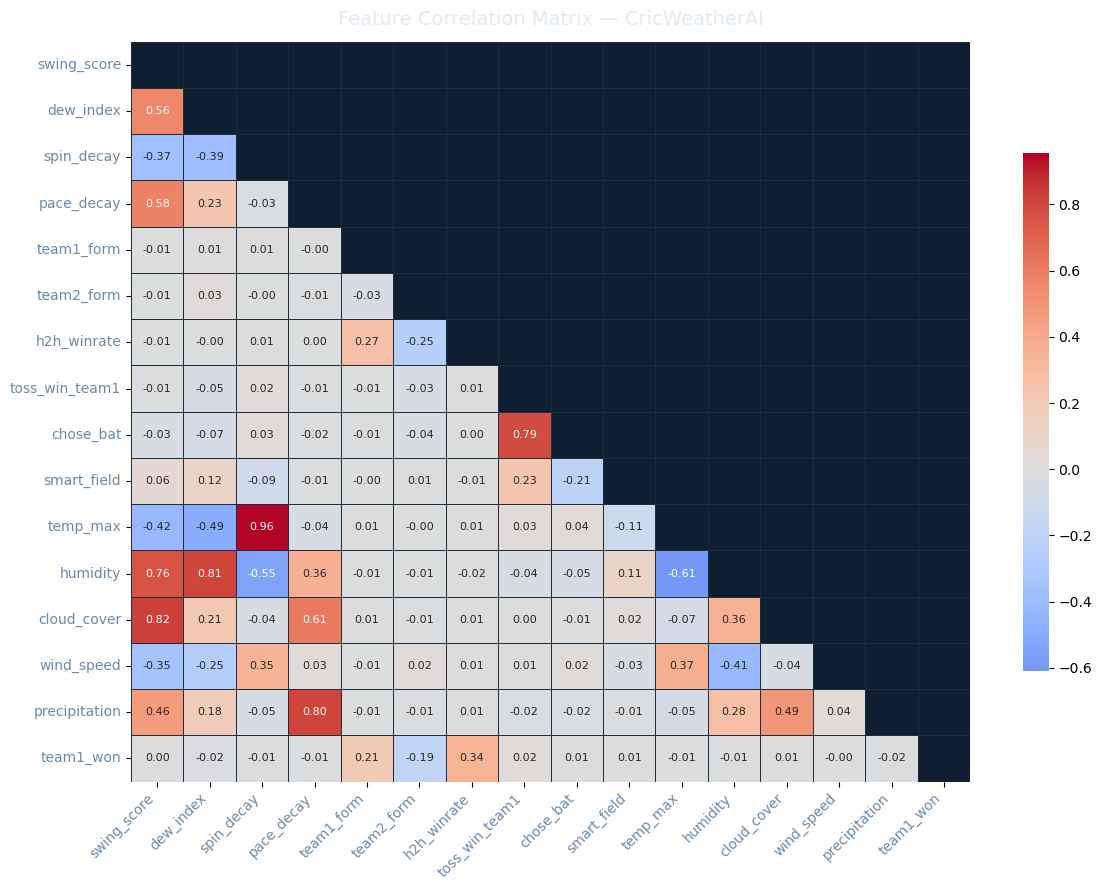

✅ Notebook 2 complete. Run 03_model_training.ipynb next.


In [10]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────

plt.figure(figsize=(12, 9))
plt.rcParams['axes.facecolor']  = '#0d1f30'
plt.rcParams['figure.facecolor'] = '#0a1520'

corr = feature_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#1e2d3d',
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.7})

plt.title('Feature Correlation Matrix — CricWeatherAI',
          color='#e0eaf5', fontsize=14, pad=12)
plt.xticks(color='#6b8aaa', rotation=45, ha='right')
plt.yticks(color='#6b8aaa', rotation=0)
plt.tight_layout()
plt.savefig('data/processed/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Notebook 2 complete. Run 03_model_training.ipynb next.')